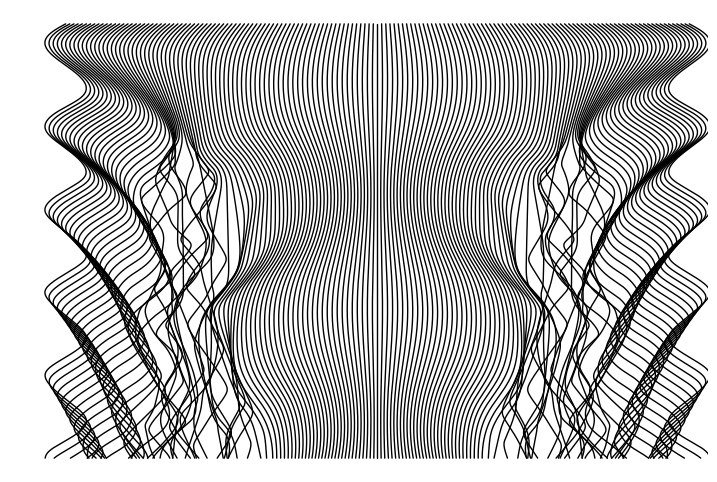

Saved SVG to 04_double_pendulum_columns_2.svg


In [41]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Physical params
# ==============================
G = 9.81
M1 = 1.0
M2 = 1.0
L1 = 1.0
L2 = 1.0
DAMP = 0.0005  # light viscous damping

# ==============================
# Simulation params
# ==============================
T_MAX = 5.0
DT = 0.01  # small step keeps tiny kicks small

# Sweep
N_COLS = 151 # odd so there is a center column
KICK_RANGE = 6.0
BASE_V = np.array([1.0, 1.6])  # [omega1, omega2] direction of kick

# Layout
FIGSIZE = (9, 6)
MARGIN_X = 0.05
MARGIN_Y = 0.03
COL_GAP = 0.00
LINE_WIDTH = 1.0
SAVE_SVG = True
SVG_PATH = "04_double_pendulum_columns_2.svg"

# Scaling behavior
NORMALIZE_PER_COLUMN = False   # False: shared global x scale across columns
INNER_PAD = 0.00               # padding inside each column [0..1]

# Plot amplitude control
AMPLIFY = 10.0  # >1 exaggerates amplitude, <1 compresses it

# ==============================
# Dynamics
# ==============================
def derivs(state):
    th1, w1, th2, w2 = state
    m1, m2, l1, l2, g = M1, M2, L1, L2, G
    d = th2 - th1
    s, c = np.sin(d), np.cos(d)

    den1 = (m1 + m2) * l1 - m2 * l1 * c * c
    den2 = (l2 / l1) * den1

    num1 = (m2 * l1 * w1 * w1 * s * c
            + m2 * g * np.sin(th2) * c
            + m2 * l2 * w2 * w2 * s
            - (m1 + m2) * g * np.sin(th1))
    dw1 = num1 / den1

    num2 = (-m2 * l2 * w2 * w2 * s * c
            + (m1 + m2) * (g * np.sin(th1) * c - l1 * w1 * w1 * s - g * np.sin(th2)))
    dw2 = num2 / den2

    dw1 -= DAMP * w1
    dw2 -= DAMP * w2
    return np.array([w1, dw1, w2, dw2], float)

def rk4_step(state, dt):
    k1 = derivs(state)
    k2 = derivs(state + 0.5 * dt * k1)
    k3 = derivs(state + 0.5 * dt * k2)
    k4 = derivs(state + dt * k3)
    return state + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

def simulate(theta1_0, omega1_0, theta2_0, omega2_0, t_max, dt):
    n = int(np.ceil(t_max / dt)) + 1
    th1 = np.empty(n)
    th2 = np.empty(n)
    state = np.array([theta1_0, omega1_0, theta2_0, omega2_0], float)
    for i in range(n):
        th1[i], _, th2[i], _ = state
        state = rk4_step(state, dt)
    return th1, th2

def x2_from_angles(th1, th2):
    return L1 * np.sin(th1) + L2 * np.sin(th2)

# ==============================
# Build sweep and simulate
# ==============================
assert N_COLS % 2 == 1
half = N_COLS // 2
sweep = np.linspace(-KICK_RANGE, KICK_RANGE, N_COLS)
sweep[half] = 0.0

# exact equilibrium start so center is static with zero kick
THETA1_INIT = 0.0
THETA2_INIT = 0.0

t = np.linspace(0.0, T_MAX, int(np.ceil(T_MAX / DT)) + 1)

# Run sims to collect x series for all columns
xs = []
for s in sweep:
    w1_0, w2_0 = (s * BASE_V).tolist()
    th1, th2 = simulate(THETA1_INIT, w1_0, THETA2_INIT, w2_0, T_MAX, DT)
    xs.append(x2_from_angles(th1, th2))
xs = np.array(xs)  # shape (N_COLS, N_time)

# Global x range if using shared scaling
if NORMALIZE_PER_COLUMN:
    global_min, global_max = None, None
else:
    global_min = np.min(xs)
    global_max = np.max(xs)
    if global_max <= global_min + 1e-12:
        global_min, global_max = 0.0, 1.0

# ==============================
# Plot on a single axis
# ==============================
fig, ax = plt.subplots(figsize=FIGSIZE)
ax.axis("off")

xmin = MARGIN_X
xmax = 1.0 - MARGIN_X
ymin = MARGIN_Y
ymax = 1.0 - MARGIN_Y

total_gap = (N_COLS - 1) * COL_GAP
col_w = (xmax - xmin - total_gap) / N_COLS
y = ymin + (t / T_MAX) * (ymax - ymin)

for i in range(N_COLS):
    # apply amplitude exaggeration for plotting only
    x = xs[i] * AMPLIFY

    if NORMALIZE_PER_COLUMN:
        x_min, x_max = np.min(x), np.max(x)
    else:
        x_min, x_max = global_min * AMPLIFY, global_max * AMPLIFY

    if x_max <= x_min + 1e-12:
        x_norm = np.full_like(x, 0.5)
    else:
        x_norm = (x - x_min) / (x_max - x_min)
        x_norm = INNER_PAD + (1 - 2*INNER_PAD) * x_norm

    x_left = xmin + i * (col_w + COL_GAP)
    x_plot = x_left + x_norm * col_w * AMPLIFY
    ax.plot(x_plot, y, "k", lw=LINE_WIDTH, solid_joinstyle="round", solid_capstyle="round")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.invert_yaxis()

if SAVE_SVG:
    plt.savefig(SVG_PATH, format="svg", bbox_inches="tight", pad_inches=0)
plt.show()
print(f"Saved SVG to {SVG_PATH}")
